# Audio Declipping
   
*   Mykola Liashuha
*   Jose Gonzalez Lopez

# Introduction
The audio declipping problem is a type of inverse problem is signal processig in where we can use the iterative thresholding algorithms and the principle of social sparsity to solve it. Our main objective will be to comment the results given in [1] in which we will base our audio declipping problem and solution by using a toy audio example. Later, we will move into the discussion of the algorithm itself, analyse it carefully and try to find any strenghts, weaknesses or parameter limitations that the solution may have for other equivalent inverse problems.

# Imports

In [50]:
import scipy #Library for signal analysis
import matplotlib.pyplot as plt #Plot
import numpy as np #Operations
import cv2 #Read images and do operations
import IPython.display as ipd
import numpy.random #For generating noise
import copy
import ltfatpy #Tool for analysis

from copy import deepcopy

from numpy import linalg

from ltfatpy import gabtight
from ltfatpy.gabor import dgtreal
from ltfatpy.gabor import idgtreal

from scipy import signal
from scipy.io import wavfile #Read wavfiles
from scipy.signal import welch,stft,istft #Get power density estimated, short fourier transform

#Numerical tools imports
from __future__ import division
from nt_toolbox.general import *
from nt_toolbox.signal import *
from nt_toolbox.perform_wavelet_transf import *
%load_ext autoreload
%autoreload 2
%pylab inline
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Populating the interactive namespace from numpy and matplotlib


# Auxiliar Functions

In [3]:
'''
Read the audio file properly, there are problems if we do not cast to double
wavfile_name: the path to the wavfile
'''
def read_file_PROPERLY(wavfile_name):
    samplerate_music, data_music = wavfile.read(wavfile_name) #Read the file
    data_music=data_music.astype(np.double)/2**15
    return samplerate_music,data_music

# Data
We will be using the music signal as the previous notebooks. We will do some basic data exploration to listen to the melody and see the data plotted in 2D.

In [7]:
samplerate_music, data_music = read_file_PROPERLY("music.wav") #Read the file
T = len(data_music) #Important to keep number of samples
ipd.Audio(data_music, rate=samplerate_music)

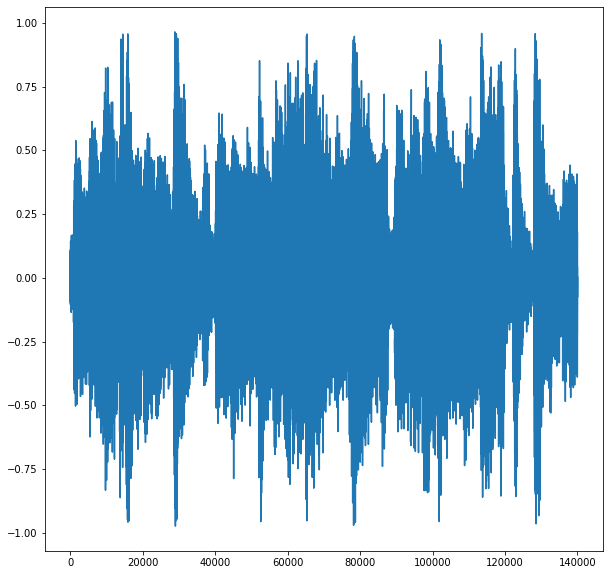

In [8]:
plt.figure(figsize=(10,10))
plt.plot(data_music)

# Audio Clipping

Clipping in general means a  particular inverse problem in which if a signal’s amplitude exceeds a certain threshold it will be trimmed. For clipped signals, compared to other problems as inpaiting, we have "some" information of the missing values. The resulting signal truncation usually leads to a very unpleasant digital distortion. [1] We will first then generate the problem by reading the music file and then trimming it to a certain threshold. 

In [9]:
threshold=0.25 #We can change this to any value, but has to be in range of the music data
clipped_audio=deepcopy(data_music) #Copy of the original data, so we do not corrupt it
clipped_audio[np.abs(clipped_audio)>threshold]=threshold

In [10]:
ipd.Audio(clipped_audio, rate=samplerate_music)

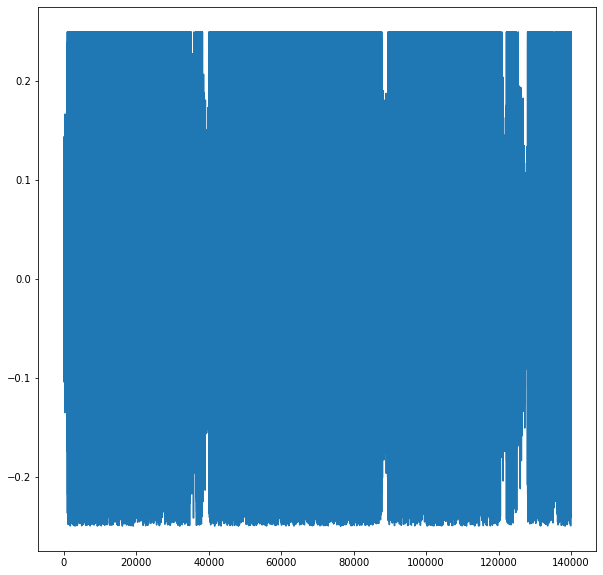

In [11]:
plt.figure(figsize=(10,10))
plt.plot(clipped_audio)

As we can see in the image and hear in the audio, the audio file has been corrupted. Our objective will be to retrieve the original audio by doing some audio declipping.

# Audio Declipping

Based on the assumption of sparse synthesis coefficients of the original signal, the declipping problem can be modeled by

\begin{equation}
α = \text{argmin}_{α}‖α‖_{0} \text{ s.t. } ‖y^{r} − M^{r}Φα‖^{2}_{2} ≤ \epsilon 
\end{equation}

Where, $α ∈ \mathbb{C}^{N}$ denotes the synthesis coefficients and $Φ ∈ \mathbb{C}^{T×N}$ the synthesis operator corresponding to the employed time-frequency dictionary (this can be the fourier domain, wavelet domain...). The vector $y^{r} = M^{r}y ∈ \mathbb{R}^{M}$ denotes the reliable samples of the observed signal $y ∈ \mathbb{R}^{T}$ , that is, the unclipped samples in the clipping case or just the available samples in the case of data packet loss. Then, $M^{r} ∈ \mathbb{R}^{M×T}$ is a matrix comprised of those rows of the identity matrix that choose the entries of the reliable samples. In [1] it is said that regarding the synthesis operator, Gabor frames (like short-time fourier transforms) have worked well with this type of problems, so we will try this operator as well as going into the wavelet domain. \\

Here, an additional constraint can be added to the first equation: reconstructed samples must be greater (in absolute value) than the clipping threshold. In analogy to the definition of $M^{r}$ , let $M^{c} ∈
\mathbb{R}^{(T−M)×T}$ denote the matrix picking the clipped samples. Also, let $θ^{\text{clip}} ∈ \mathbb{R}^{(T−M)}$ be the vector of clipped samples, taking only the values $±θ^{\text{clip}}$, in dependence on the sign of the true values in $y$. Then, for declipping, the problem becomes

\begin{equation}
\hat{\alpha} = \text{argmin}_{α} || \alpha ||_{0} \text{ s.t. } ||y^{r} − M^{r}Φα||_{2}^{2} ≤ \epsilon \text{ and } |M^{c}Φα| ≥ |θ^{\text{clip}}|
\end{equation}

Now we will create the masks and take the reliable samples from the clipped_audio and the unreliable ones.

In [20]:
#Mask for reliable samples       
m_r = np.array([1.0 if np.abs(x)<threshold else 0.0 for x in clipped_audio])
m_c = 1.0-m_r

#Realiable and clipped samples
y_r = np.multiply(clipped_audio,m_r)
y_c = np.multiply(clipped_audio,m_c)

[ 0.00549316 -0.0045166  -0.01220703 ... -0.04577637  0.00592041
  0.0428772 ]


In the other notebook of image denoising, we solved the inpainting problem (minimization problem)

\begin{equation}
\text{argmin}_{a}\cfrac{1}{2}∥y−M^{r}Ψ\alpha∥_{2}^{2}+λ||\alpha||.
\end{equation}

So, if could convert the audio declipping problem into an equivalent of this type of problem, we could use a similar approach to solve it. This convex non-smooth function can be minimized by the shrinkage/thresholding algorithm (ISTA) that we have seen in class, or its accelerated version FISTA The most straight-forward approach for obtaining a convex relaxation with linear constraints is to consider in the inpainting problem an additional constraint to choose $\alpha$, such that

\begin{equation}
|M^{c}Φα| ≥ |θ^{\text{clip}}|
\end{equation}

The only problem is that non-smooth convex problems with such constraints cannot be minimized directly by a forward-backward strategy. So, we have to find another way around. According to [1], they propose to relax the constraints by means of a squared hinge function.

\begin{equation}
h : \mathbb{R} → \mathbb{R}_{+};  z → h (z) = 
\begin{cases}
z^{2} \text{ if } z < 0\\
0 \text{ if } z \geq 0
\end{cases}
\end{equation}

By application to $z = x−θ^{\text{clip}}$ , for known clipping values $θ^{\text{clip}} > 0$, the squared hinge sets $x$ “free” if $|x| ≥ θ^{\text{clip}}$ , and penalizes otherwise. [1] Introduces then the following unconstrained convex optimization problem.

\begin{equation}
\text{argmin}_{\alpha}\cfrac{1}{2}||y^{r} − M^{r} Φα||_{2}^{2} + \cfrac{1}{2}[θ^{\text{clip}} − M^{c}Φα]^{2}_{+} + λ||α||_{1}
\end{equation}

and any algorithm from the ISTA family can be applied to solve this minimization problem

In [84]:
def gabor_forward(x,g,a,m):
    c,Ls,g =  dgtreal.dgtreal(x,g,a,M)
    return c

def gabor_inverse(x,g,a,M,T):
    f,g = idgtreal.idgtreal(x,g,a,M,T)
    return f

def maximum(x):
    return max(0,x)


def lasso_threshold(coeff,lambd):
    first = lambd/abs(coeff)
    maximun_v = np.vectorize(maximum)
    second = maximun_v(first)
    second=second.astype('complex128')
    return second

In [85]:
lambdas=np.arange(0,1,0.1)
M = 1024;
a = 256;

g = gabtight(None, a, M) #This is the window (gabor window)
c,_,_ = dgtreal.dgtreal(y_c, g, a, M) # take gabor of clipped sample

nf,nt = c.shape #Take shapes

Gdeclip = np.zeros((nf,nt),dtype=numpy.complex128)
GdeclipZ = deepcopy(Gdeclip) #Create separate copy

#100 iterations
for lambd in lambdas:
    for i in range(100):
        #forward step
        GdeclipOLD = deepcopy(Gdeclip)

        #Inverse transform
        xdeclipZ = gabor_inverse(GdeclipZ,g,a,M,T)

        #Create zeros
        r1 = np.zeros((T,))
        #Apply with mask
        r1 = r1 + (y_r - np.multiply(xdeclipZ,m_c))

        #Take g1
        grad1 = -gabor_forward(r1,g,a,M)
        
        #Now r2
        r2 = np.zeros((T,))
        r2 = r2 + (y_c - np.multiply(xdeclipZ,m_c))
        
        #Take which elements of xclipz are below threshold
        indexes = np.array([0 if abs(elem)>threshold else 1 for elem in xdeclipZ])
        r2 = np.multiply(r2,indexes)
        
        grad2 = -gabor_forward(r2,g,a,M)
        
        #Update
        GdeclipZ = GdeclipZ - grad1 - grad2


        #Thresholding step
        Gdeclip = lasso_threshold(GdeclipZ, lambd)

        #Relaxation term
        GdeclipZ = Gdeclip + (i-1)/(i+5) * (Gdeclip - GdeclipOLD)
        
        if(i%10==0):
            print(i)


reconstructed_signal = gabor_inverse(Gdeclip,g,a,M,T)

0
10
20
30
40
50
60
70
80
90
0
10
20
30
40
50
60
70
80
90
0
10
20
30
40
50
60
70
80
90
0
10
20
30
40
50
60
70
80
90
0
10
20
30
40
50
60
70
80
90
0
10
20
30
40
50
60
70
80
90
0
10
20
30
40
50
60
70
80
90
0
10
20
30
40
50
60
70
80
90
0
10
20
30
40
50
60
70
80
90
0
10
20
30
40
50
60
70
80
90


In [86]:
ipd.Audio(reconstructed_signal, rate=samplerate_music)

# References
[1] Kai Siedenburg, Matthieu Kowalski, Monika Dörfler. Audio Declipping with Social Sparsity. IEEE
International Conference on Acoustics, Speech and Signal Processing (ICASSP 2014), May 2014,
Florence, Italy. pp.AASP-L2. hal-01002998